In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/scan_project

/content/drive/MyDrive/scan_project


In [3]:
!ls

data  data_utils  evaluation  jump_result.csv  models  turn_left_result.csv


In [4]:
import torch
from torch.utils.data import Dataset
from data_utils.scan_helpers import BOS, EOS


class ScanDataset(Dataset):
    def __init__(self, inputs, outputs, src_vocab, tgt_vocab):
        self.inputs = inputs
        self.outputs = outputs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        src = [self.src_vocab[t] for t in self.inputs[idx]]
        tgt = [self.tgt_vocab[t] for t in self.outputs[idx]]

        tgt_input = [BOS] + tgt
        tgt_output = tgt + [EOS]

        return (
            torch.tensor(src, dtype=torch.long),
            torch.tensor(tgt_input, dtype=torch.long),
            torch.tensor(tgt_output, dtype=torch.long),
        )

In [5]:
import torch
import torch.nn as nn
import numpy as np
import random
from torch.utils.data import DataLoader, Dataset

# ==============================
# Device & seed
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# ==============================
# SCAN helpers
# ==============================
from data_utils.scan_helpers import (
    load_scan_split,
    build_vocab,
    PAD,
    BOS,
    EOS,
)

# ==============================
# Evaluation
# ==============================
from evaluation.scan_evaluation import (
    greedy_decode,
    sequence_accuracy,
    evaluate_sequence_accuracy,
    evaluate_token_level,
    evaluate_ordered_token_accuracy,
)

# ==============================
# Dataset / model
# ==============================
from data_utils.scan_dataset import ScanDataset
from data_utils.scan_dataloader import collate_scan_batch
from models.transformer import Transformer


In [6]:
print("PyTorch version:", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.9.0+cu126
Using device: cuda
GPU: Tesla T4


In [7]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)


## Load SCAN & Create Vocabulary

In [8]:
EXPERIMENT = "jump"   # "jump" | "turn_left"

In [9]:
# ==============================
# Load SCAN add-primitive split
# ==============================

scan_dir = "data"

if EXPERIMENT == "jump":
    train_path = f"{scan_dir}/tasks_train_addprim_jump.txt"
    test_path  = f"{scan_dir}/tasks_test_addprim_jump.txt"

elif EXPERIMENT == "turn_left":
    train_path = f"{scan_dir}/tasks_train_addprim_turn_left.txt"
    test_path  = f"{scan_dir}/tasks_test_addprim_turn_left.txt"

else:
    raise ValueError(f"Unknown EXPERIMENT: {EXPERIMENT}")

train_inputs, train_outputs = load_scan_split(train_path)
test_inputs, test_outputs   = load_scan_split(test_path)

print(f"Experiment: {EXPERIMENT}")
print(f"Train samples: {len(train_inputs)}")
print(f"Test samples:  {len(test_inputs)}")

Experiment: jump
Train samples: 14670
Test samples:  7706


In [10]:
source_vocab = build_vocab(train_inputs)
target_vocab = build_vocab(train_outputs)

print("Source vocab size:", len(source_vocab))
print("Target vocab size:", len(target_vocab))

Source vocab size: 16
Target vocab size: 9


In [11]:
train_dataset = ScanDataset(
    train_inputs,
    train_outputs,
    source_vocab,
    target_vocab,
)

test_dataset = ScanDataset(
    test_inputs,
    test_outputs,
    source_vocab,
    target_vocab,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_scan_batch,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_scan_batch,
)


In [12]:
EMB_DIM = 128
N_LAYERS = 2
N_HEADS = 8
FORWARD_DIM = 256
DROPOUT = 0.15

LEARNING_RATE = 2e-4
GRAD_CLIP = 1
BATCH_SIZE = 16


In [13]:
model = Transformer(
    src_vocab_size=len(source_vocab),
    tgt_vocab_size=len(target_vocab),
    src_pad_idx=PAD,
    tgt_pad_idx=PAD,
    emb_dim=EMB_DIM,
    num_layers=N_LAYERS,
    num_heads=N_HEADS,
    forward_dim=FORWARD_DIM,
    dropout=DROPOUT,
    max_len=128,
).to(device)

In [14]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)


In [15]:
# SANITY CHECK
source_batch, target_input, target_output = next(iter(train_loader))
print(source_batch.shape, target_input.shape, target_output.shape)


torch.Size([16, 9]) torch.Size([16, 28]) torch.Size([16, 28])


In [16]:
EPOCHS = 4

In [17]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [18]:
# ==============================
# TRAINING LOOP (SCAN — correct)
# ==============================

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for source_seq, target_input, target_output in train_loader:
        source_seq = source_seq.to(device)
        target_input = target_input.to(device)
        target_output = target_output.to(device)

        optimizer.zero_grad()

        logits = model(source_seq, target_input)

        loss = criterion(
            logits.view(-1, logits.size(-1)),
            target_output.view(-1),
        )

        loss.backward()

        # REQUIRED gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={running_loss / len(train_loader):.4f}"
    )

Epoch 01 | train_loss=0.6340
Epoch 02 | train_loss=0.3895
Epoch 03 | train_loss=0.2214
Epoch 04 | train_loss=0.1634


In [19]:
# ==============================
# FINAL EVALUATION
# ==============================
final_val_loss, final_tok_acc = evaluate_token_level(
    model,
    test_loader,
    criterion,
    device,
)

final_seq_acc = evaluate_sequence_accuracy(
    model,
    test_loader,
    device,
)

print("\nFINAL EVALUATION")
print(f"Experiment: {EXPERIMENT}")
print(f"Token-level accuracy:    {final_tok_acc * 100:.2f}%")
print(f"Sequence-level accuracy: {final_seq_acc * 100:.2f}%")



FINAL EVALUATION
Experiment: jump
Token-level accuracy:    63.42%
Sequence-level accuracy: 1.10%


In [20]:
# ==============================
# Save results
# ==============================
import pandas as pd

results = {
    "experiment": EXPERIMENT,
    "epochs": EPOCHS,
    "token_accuracy": final_tok_acc,
    "sequence_accuracy": final_seq_acc,
}

if EXPERIMENT == "jump":
    RESULTS_PATH = "jump_result.csv"
elif EXPERIMENT == "turn_left":
    RESULTS_PATH = "turn_left_result.csv"
else:
    raise ValueError(f"Unknown EXPERIMENT: {EXPERIMENT}")

df = pd.DataFrame([results])
df.to_csv(RESULTS_PATH, index=False)

print(f"\nResults saved to {RESULTS_PATH}")



Results saved to jump_result.csv


In [21]:
from torch.utils.data import DataLoader
import torch
import torch.nn as nn

def run_jump_experiment(
    k,
    base_train_inputs,
    base_train_outputs,
    base_test_inputs,
    base_test_outputs,
    src_vocab,
    tgt_vocab,
    device,
    epochs=4,
    seed=42,
    max_k=32,
):
    """
    Experiment 3 JUMP curve (correct protocol):
    - take first max_k composed jump examples from TEST as a pool
    - add first k of them to TRAIN
    - evaluate on remaining TEST examples (excluding those k)
    """

    # ---- determinism
    seed_everything(seed)

    # =====================================================
    # 1) choose pool of composed jump commands from TEST
    # =====================================================
    # (в jump-test обычно все команды составные и содержат jump, но фильтр оставим на всякий)
    pool_idx = [
        i for i, inp in enumerate(base_test_inputs)
        if len(inp) > 1 and "jump" in inp
    ]
    pool_idx = pool_idx[:max_k]   # детерминированно

    add_idx = pool_idx[:k]        # эти k мы ДОБАВИМ в train

    # =====================================================
    # 2) build TRAIN = base train + k examples from test pool
    # =====================================================
    train_inputs  = list(base_train_inputs)  + [base_test_inputs[i]  for i in add_idx]
    train_outputs = list(base_train_outputs) + [base_test_outputs[i] for i in add_idx]

    # =====================================================
    # 3) build EVAL TEST = base test minus those k used for training
    # =====================================================
    add_set = set(add_idx)
    eval_idx = [i for i in range(len(base_test_inputs)) if i not in add_set]

    eval_inputs  = [base_test_inputs[i]  for i in eval_idx]
    eval_outputs = [base_test_outputs[i] for i in eval_idx]

    # =====================================================
    # 4) datasets & loaders
    # =====================================================
    train_ds = ScanDataset(train_inputs, train_outputs, src_vocab, tgt_vocab)
    test_ds  = ScanDataset(eval_inputs,  eval_outputs,  src_vocab, tgt_vocab)

    train_dl = DataLoader(
        train_ds,
        batch_size=16,
        shuffle=True,
        collate_fn=collate_scan_batch,
    )
    test_dl = DataLoader(
        test_ds,
        batch_size=64,
        shuffle=False,
        collate_fn=collate_scan_batch,
    )

    # =====================================================
    # 5) model / optim
    # =====================================================
    model = Transformer(
        src_vocab_size=len(src_vocab),
        tgt_vocab_size=len(tgt_vocab),
        src_pad_idx=PAD,
        tgt_pad_idx=PAD,
        emb_dim=128,
        num_layers=2,
        num_heads=8,
        forward_dim=256,
        dropout=0.15,
        max_len=128,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)

    # =====================================================
    # 6) training
    # =====================================================
    for _ in range(epochs):
        model.train()
        for src, tgt_in, tgt_out in train_dl:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)

            optimizer.zero_grad()
            logits = model(src, tgt_in)
            loss = criterion(logits.view(-1, logits.size(-1)), tgt_out.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    # =====================================================
    # 7) evaluation
    # =====================================================
    _, token_acc = evaluate_token_level(model, test_dl, criterion, device)

    seq_non = evaluate_sequence_accuracy(
        model,
        test_dl,
        device,
        use_oracle=False,
    )

    seq_or = evaluate_sequence_accuracy(
        model,
        test_dl,
        device,
        use_oracle=True,
    )


    return token_acc * 100, seq_non * 100, seq_or * 100


In [27]:
ks = [0, 1, 2, 4, 8, 16, 32]

token_accs = []
seq_accs_non = []
seq_accs_or = []

for k in ks:
    print(f"\n=== JUMP experiment: k={k} ===")

    tok, seq_non, seq_or = run_jump_experiment(
        k=k,
        base_train_inputs=train_inputs,
        base_train_outputs=train_outputs,
        base_test_inputs=test_inputs,
        base_test_outputs=test_outputs,
        src_vocab=source_vocab,
        tgt_vocab=target_vocab,
        device=device,
        epochs=4,
        seed=42,
        max_k=32,
    )

    token_accs.append(tok)
    seq_accs_non.append(seq_non)
    seq_accs_or.append(seq_or)

    print(
        f"Token acc: {tok:.2f}% | "
        f"Seq acc (non-oracle): {seq_non:.2f}% | "
        f"Seq acc (oracle): {seq_or:.2f}%"
    )


=== JUMP experiment: k=0 ===
Token acc: 64.27% | Seq acc (non-oracle): 0.51% | Seq acc (oracle): 1.36%

=== JUMP experiment: k=1 ===
Token acc: 64.54% | Seq acc (non-oracle): 0.82% | Seq acc (oracle): 1.89%

=== JUMP experiment: k=2 ===
Token acc: 65.15% | Seq acc (non-oracle): 1.21% | Seq acc (oracle): 2.56%

=== JUMP experiment: k=4 ===
Token acc: 65.36% | Seq acc (non-oracle): 0.87% | Seq acc (oracle): 2.57%

=== JUMP experiment: k=8 ===
Token acc: 68.50% | Seq acc (non-oracle): 3.01% | Seq acc (oracle): 6.05%

=== JUMP experiment: k=16 ===
Token acc: 84.23% | Seq acc (non-oracle): 9.34% | Seq acc (oracle): 22.90%

=== JUMP experiment: k=32 ===
Token acc: 88.74% | Seq acc (non-oracle): 15.66% | Seq acc (oracle): 37.35%


In [28]:
print("k values:               ", ks)
print("Token accuracies (%):   ", [f"{v:.2f}" for v in token_accs])
print("Seq acc (non-oracle %): ", [f"{v:.2f}" for v in seq_accs_non])
print("Seq acc (oracle %):     ", [f"{v:.2f}" for v in seq_accs_or])

k values:                [0, 1, 2, 4, 8, 16, 32]
Token accuracies (%):    ['64.27', '64.54', '65.15', '65.36', '68.50', '84.23', '88.74']
Seq acc (non-oracle %):  ['0.51', '0.82', '1.21', '0.87', '3.01', '9.34', '15.66']
Seq acc (oracle %):      ['1.36', '1.89', '2.56', '2.57', '6.05', '22.90', '37.35']


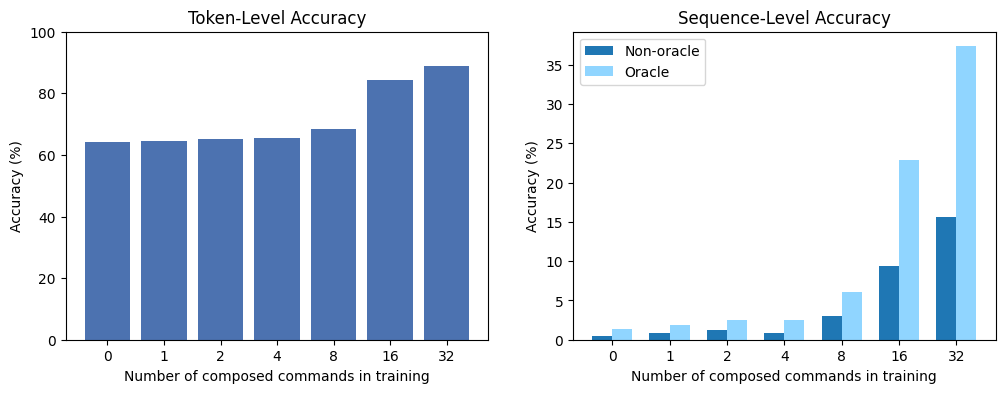

In [34]:
# =========================
# VISUALIZATION (clean colors)
# =========================

x = np.arange(len(ks))

plt.figure(figsize=(12, 4))

# --- Token-level accuracy ---
plt.subplot(1, 2, 1)
plt.bar(
    x,
    token_accs,
    color="#4C72B0",   # muted blue
)
plt.xticks(x, ks)
plt.ylim(0, 100)
plt.title("Token-Level Accuracy")
plt.xlabel("Number of composed commands in training")
plt.ylabel("Accuracy (%)")
# --- Sequence-level accuracy ---
plt.subplot(1, 2, 2)

bar_width = 0.35

plt.bar(
    x - bar_width / 2,
    seq_accs_non,
    width=bar_width,
    label="Non-oracle",
    color="#1f77b4",   # blue
)

plt.bar(
    x + bar_width / 2,
    seq_accs_or,
    width=bar_width,
    label="Oracle",
    color="#90D5FF",
)

plt.xticks(x, ks)
plt.title("Sequence-Level Accuracy")
plt.xlabel("Number of composed commands in training")
plt.ylabel("Accuracy (%)")
plt.legend()


